## Alcanzando los objetivos de desarrollo sostenible.
## Un aporte desde el machine learning.

La Organización de las Naciones Unidas (ONU) adopta, el 25 de septiembre del año 2015, la Agenda 2030 para el desarrollo sostenible, cuyo fin es reducir la pobreza, garantizar acceso a la salud y educación, buscar igualdad de género y oportunidades y disminuir el impacto ambiental, entre otros propósitos. A tal efecto, define 17 objetivos de desarrollo sostenible (ODS) y 169 metas (derivadas de los diferentes ODS). Dentro del trabajo en conjunto de diferentes entes para alcanzar el cumplimiento de los objetivos de desarrollo sostenible definidos en la Agenda 2030, muchas entidades tienen como función el seguimiento y la evaluación de las políticas públicas y su impacto a nivel social. Este es el caso del Fondo de Población de las Naciones Unidas (UNFPA, por sus siglas en inglés), que, junto con instituciones públicas y haciendo uso de diferentes herramientas de participación ciudadana, busca identificar problemas y evaluar soluciones actuales, relacionando la información con los diferentes ODS.
Uno de los procesos que requiere de un mayor esfuerzo es la interpretación y análisis de la información textual procedente de diferentes fuentes implicadas en la planeación participativa para el desarrollo a nivel territorial, ya que es una tarea que consume gran cantidad recursos y para la cual se requiere de expertos que relacionen los textos con los ODS. Este conocimiento facilitaría la toma de decisiones con base en la opinión de la población y permitiría encaminar las políticas públicas de manera más informada para el cumplimiento de la Agenda 2030.
El objetivo del proyecto es desarrollar una solución, basada en técnicas de procesamiento del lenguaje natural y machine learning, que permita clasificar automáticamente un texto según los 17 ODS, ofreciendo una forma de presentación de resultados a través de una herramienta de fácil comprensión para el usuario final.

### A. Objetivo.

Desarrollar una solución, basada en técnicas de procesamiento de lenguaje natural y machine learning, que facilite la interpretación y análisis de información textual para la identificación de relaciones semánticas con los Objetivos de Desarrollo Sostenibles.


### B. Conjunto de datos.

El conjunto de datos forma parte del proyecto “OSDG Community Dataset”1 (OSDG-CD), en su versión 2023, que contiene un total de 40.067 textos, de los cuales 3000 provienen de fuentes relacionadas con las Naciones Unidas. También contiene documentos públicos, resúmenes de artículos y reportes. La plataforma reúne investigadores, expertos en la materia y defensores de los ODS de todo el mundo para crear una fuente amplia y precisa de información textual sobre los ODS. Los voluntarios de la comunidad utilizan la plataforma para participar en ejercicios de etiquetado en los que validan la relevancia de cada texto para los ODS basándose en sus conocimientos previos.
Los textos que serán utilizados en este proyecto han sido traducidos al español por herramientas como Deepl2. También se realizó una aumentación de textos a través del API de ChatGPT3.

### C. Actividades para realizar.

1. Preparación de los textos utilizando el esquema de bolsa de palabras (BOW)l con una pesado TF-IDF. Para este paso construir un pipeline que integre las transformaciones que se consideren adecuadas.

2. A partir de la matriz TF-IDF construida en el paso anterior, aplica el algoritmo SVD truncado (TruncatedSVD de scikit-learn) para obtener un modelo de tópicos mediante análisis semántico latente (LSA). Explora un número reducido de componentes (por ejemplo, entre 10 y 20) y, para al menos 5 de ellas, identifica y muestra las palabras con mayor peso a modo de "tópicos". Interpreta cualitativamente si estos tópicos guardan relación con algunos de los 17 ODS trabajados en el proyecto.

3. Desarrollo de un modelo de clasificación que permita relacionar un texto con un ODS. Para manejar la complejidad del espacio de entrada, puedes reutilizar la misma descomposición SVD obtenida en la actividad anterior (LSA), o aplicar otro algoritmo de reducción de la dimensionalidad que consideres pertinente.

4. Evaluación del modelo con textos que no hayan sido utilizados para el aprendizaje.

### D. Consideraciones.

El algoritmo de clasificación a utilizar, así como la técnica de reducción de la dimensionalidad, queda a consideración de cada grupo, pero es importante justificar la elección.

## 1. Importación de librerias:

In [1]:
!pip install gensim

In [2]:
import pandas as pd
import numpy as np
import nltk
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem.snowball import SnowballStemmer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

In [3]:
# Descarga diccionario de stopwords o palabras vacias
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\josar\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## 2. Carga de dataset:

In [4]:
# 1. Cargar el archivo Excel en un DataFrame
df = pd.read_excel('../dataset/Datos_textosODS.xlsx')

## 3. Exploración de datos:

In [5]:
df.head()

,textos,ODS
0,"""Aprendizaje"" y ""educación"" se consideran sinó...",4
1,No dejar clara la naturaleza de estos riesgos ...,6
2,"Como resultado, un mayor y mejorado acceso al ...",13
3,Con el Congreso firmemente en control de la ju...,16
4,"Luego, dos secciones finales analizan las impl...",5


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9656 entries, 0 to 9655
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   textos  9656 non-null   str  
 1   ODS     9656 non-null   int64
dtypes: int64(1), str(1)
memory usage: 151.0 KB


### Verificación de valores nulos y duplicados:

In [7]:
df.isna().sum()

textos    0
ODS       0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

### No se encuentran valores nulos ni duplicados.

## 4. Separación de datos.

### Separación de variable objetivo

In [9]:
X = df["textos"]

In [10]:
y = df["ODS"]

### Separación en datos de entrenamiento y test:

Esta separación se hace para entrenar y evaluar el modelo de clasificación que se creará más adelante

In [11]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

## 5. Preprocesamiento de texto

### 5.1 Función de preprocesamiento.

Su objetivo es normalizar, limpiar y transformar el texto recibido en español mediante técnicas de NLP (Procesamiento del Lenguaje Natural), con el fin de reducir la dimensionalidad del vocabulario y extraer los rasgos léxicos/semánticos fundamentales (stems) antes de la vectorización TF-IDF.

In [12]:
def preprocess_text(text):

    """
    Propósito:
    ----------
    Normalizar y limpiar texto libre en español aplicando tokenización por expresión regular,
    remoción de palabras vacías (stopwords) y estematización (stemming) con Snowball.

    Entradas:
    ---------
    text : str u objeto convertible a cadena
        Texto libre en bruto correspondiente al documento o propuesta de entrada.

    Salidas:
    --------
    str
        Cadena de texto procesada con tokens filtrados y estematizados unidos por espacio.
    """

    # Utilizamos la clase RegexpTokenizer() para realizar una tokenización personalizada.
    # Con la expresión regular \w+, indicaremos que solo queremos conservar las palabras:
    tokenizer = RegexpTokenizer(r'\w+')

    # Convertir texto a minúscula para validar contra palabras vacias, las cuales se encuentran en minúscula
    tokens = tokenizer.tokenize(str(text).lower())

    # Cargar stopwords/ palabras vacias en español
    spanish_stopwords = set(stopwords.words('spanish'))

    # Excluir palabras vacias en español
    tokens = [token for token in tokens if token not in spanish_stopwords]

    # Stemmer en español (Snowball)
    # Reducción de cada token a su forma más general
    # En este caso utilizaremos la clase SnowballStemmer
    stemmer = SnowballStemmer('spanish')
    tokens = [stemmer.stem(token) for token in tokens]

    return ' '.join(tokens)

## 5. 2 Pipeline de preprocesamiento utilizando pesado TF-IDF:

* **Propósito:**  
  Definir un pipeline secuencial de extracción de características enfocado en transformar el texto en bruto en una matriz numérico-espacial de frecuencias mediante el algoritmo **TF-IDF** (*Term Frequency - Inverse Document Frequency*), integrando la función de limpieza personalizada (preprocess_text) y aplicando filtros léxicos y n-gramas.

* **Entradas:**  
  Conjunto de documentos de texto libre en lenguaje natural.

* **Salidas:**  
  * matriz dispersa (*scipy.sparse.csr_matrix*): Matriz donde las filas representan los documentos y las columnas representan las ponderaciones numéricas TF-IDF de los unigramas y bigramas seleccionados.

---

#### Parámetros Configurados en TfidfVectorizer:

1. **preprocessor=preprocess_text**:  
   Enlaza la función personalizada de preprocesamiento, garantizando que el texto pase por la conversión a minúsculas, tokenización, eliminación de *stopwords* en español y estematización (*stemming* con Snowball) antes de la extracción de características.

2. **min_df=2 (*Minimum Document Frequency*):**  
   Filtra y remueve los términos que aparecen en menos de 2 documentos de todo el corpus. Ayuda a reducir el ruido causado por errores tipográficos, palabras extremadamente raras o atípicas (*outliers*).

3. **max_df=0.50 (*Maximum Document Frequency*):**  
   Descarta los términos que están presentes en más del 50% de los documentos. Elimina palabras que, aunque no sean *stopwords* estándar, son demasiado comunes en el dominio de los ODS y carecen de poder discriminatorio entre clases.

4. **ngram_range=(1, 2):**  
   Especifica la extracción tanto de palabras individuales (**unigramas**) como de pares contiguos de palabras (**bigramas**). Permite capturar términos compuestos fundamentales para el contexto de los ODS (ej. *"cambio climático"*, *"agua limpia"*, *"pobreza extrema"*).

In [13]:
# Pipeline exclusivo de preprocesamiento y extracción TF-IDF
preprocessing_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        preprocessor=preprocess_text,
        min_df=2, # Elimina palabras con menos de 2 apariciones en todo el corpus.
        max_df=0.50, #Elimina palabras que estén en más del 50% de los textos
        ngram_range=(1, 2) # Incluido para capturar unigramas y bigramas
    ))
])

### Ejecución pipeline de preprocesamiento


* **Propósito:**  
  Ejecutar el pipeline de extracción de características (preprocessing_pipeline) para transformar los conjuntos de texto (x_train y x_test) en matrices numéricas de términos ponderados por **TF-IDF**, garantizando el aislamiento estricto entre los datos de entrenamiento y prueba para evitar la fuga de información (*data leakage*).

* **Entradas:**  
  * x_train (*Series/Lista*): Textos en bruto asignados al conjunto de entrenamiento.
  * x_test (*Series/Lista*): Textos en bruto asignados al conjunto de prueba/evaluación.

* **Salidas:**  
  * x_train_tfidf (*scipy.sparse.csr_matrix*): Matriz dispersa de entrenamiento con dimensiones $(N_{\text{train}}, M_{\text{voc}})$, donde $N$ es el número de documentos y $M$ la cantidad de unigramas y bigramas aprendidos.
  * x_test_tfidf (*scipy.sparse.csr_matrix*): Matriz dispersa de prueba proyectada sobre las $M_{\text{voc}}$ columnas del vocabulario de entrenamiento.

---

#### **Ejecución:**

1. **fit_transform(x_train):**
   * **fit:** Analiza el conjunto de entrenamiento para construir el vocabulario de unigramas y bigramas y calcular la frecuencia inversa de documento ($IDF$).
   * **transform:** Preprocesa los textos de x_train y genera la matriz numérico-espacial ponderada.

2. **transform(x_test):**
   * Proyecta el conjunto de prueba exclusivamente sobre el vocabulario y métricas $IDF$ previamente aprendidas de `x_train`.
   * **Garantía metodológica:** Previene la fuga de datos (*data leakage*), asegurando que el modelo no conozca información léxica del conjunto test durante el ajuste.

3. **Verificación de Dimensiones (.shape):**
   * Confirma que ambas matrices compartan exactamente la misma cantidad de columnas (rasgos/términos), variando únicamente en el número de filas (registros de cada partición).

In [14]:
# Transformación de los conjuntos de entrenamiento y test
# .fit_transform() sobre x_train para aprender el vocabulario y transformar
x_train_tfidf = preprocessing_pipeline.fit_transform(x_train)

# .transform() proyecta x_test usando el vocabulario ya aprendido
x_test_tfidf = preprocessing_pipeline.transform(x_test)

print("Dimensiones de la matriz TF-IDF (Entrenamiento):", x_train_tfidf.shape)
print("Dimensiones de la matriz TF-IDF (Prueba):", x_test_tfidf.shape)

Dimensiones de la matriz TF-IDF (Entrenamiento): (7724, 62738)
Dimensiones de la matriz TF-IDF (Prueba): (1932, 62738)


In [15]:
# Inspeccionar la lista de palabras/raíces que conforman el vocabulario extraído.
preprocessing_pipeline.named_steps['tfidf'].get_feature_names_out()

array(['00', '000', '000 2000', ..., 'zonif part', 'zonific', 'ñam'],
      shape=(62738,), dtype=object)

## 6. Construcción modelo de tópicos.

A partir de la matriz TF-IDF construida en el paso anterior, aplica el algoritmo SVD truncado (TruncatedSVD de scikit-learn) para obtener un modelo de tópicos mediante análisis semántico latente (LSA). Explora un número reducido de componentes (por ejemplo, entre 10 y 20) y, para al menos 5 de ellas, identifica y muestra las palabras con mayor peso a modo de "tópicos". Interpreta cualitativamente si estos tópicos guardan relación con algunos de los 17 ODS trabajados en el proyecto.

### 6.1 A continuación se define función "aplicar_lsa" para construir modelo de tópicos mediante LSA aplicando algoritmo TruncatedSVD.

Fuente: [https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD]

* **Propósito:**  
  Realizar una reducción de dimensionalidad mediante el método **LSA** (*Latent Semantic Analysis* / Análisis Semántico Latente) aplicando la desintegración en valores singulares truncada (**TruncatedSVD**). Permite comprimir el espacio disperso de la matriz TF-IDF a una representación densa de conceptos abstractos (componentes latentes), mitigando el problema de la "maldición de la dimensionalidad" y agrupando palabras que comparten contextos similares o que suelen aparecer juntas en los textos.

* **Entradas:**  
  * X_tfidf (*scipy.sparse matrix*): Matriz dispersa de términos TF-IDF obtenida en la etapa de vectorización.
  * vectorizer (*TfidfVectorizer*): Instancia del vectorizador de scikit-learn previamente ajustado (fit), de la cual se extraen los nombres de los unigramas y bigramas del vocabulario.
  * n_components (*int*, opcional, por defecto `100`): Número de dimensiones o temas latentes a extraer (valor estándar recomendado en literatura para LSA).
  * random_state (*int*, opcional, por defecto `0`): Semilla aleatoria que asegura la reproducibilidad de la descomposición matricial.

* **Salidas:**  
  * lsa_model (*TruncatedSVD*): Objeto del modelo entrenado que contiene los pesos de los componentes y la varianza explicada.
  * X_lsa (*numpy.ndarray*): Matriz densa transformada con dimensiones reducidas $(N_{\text{documentos}}, n\_components)$.
  * feature_names (*numpy.ndarray*): Arreglo unidimensional que contiene la lista ordenada del vocabulario extraído del vectorizador.

---

#### Flujo de Operaciones:

1. **Instanciación y Descomposición:**  
   Inicializa la clase TruncatedSVD ajustándola sobre la matriz X_tfidf mediante .fit_transform() para proyectar las observaciones a las $N$ dimensiones latentes.
2. **Extracción del Vocabulario:**  
   Obtiene el arreglo de términos a través del método  .get_feature_names_out() del vectorizador y lo mapea como un *array* de NumPy para facilitar búsquedas o evaluaciones de coherencia temáticas posteriores.
3. **Métrica de Diagnóstico (Varianza Explicada):**  
   Calcula la varianza explicada acumulada mediante el sumatorio de explained_variance_ratio_ e imprime el porcentaje global de información retenida por las $N$ componentes latentes elegidas.

In [16]:
def aplicar_lsa(X_tfidf, vectorizer, n_components=100, random_state=0):
    """
    Aplica TruncatedSVD (LSA) sobre una matriz TF-IDF.

    Parámetros:
    - X_tfidf: Matriz TF-IDF (scipy sparse matrix).
    - vectorizer: Objeto TfidfVectorizer ajustado (para extraer vocabulario).
    - n_components: Número de componentes latentes (por defecto 100 según recomendación en Scikit-Learn para LSA).
    - random_state: Semilla de aleatoriedad.

    Retorna:
    - lsa_model: Objeto TruncatedSVD entrenado.
    - X_lsa: Matriz transformada con dimensiones reducidas.
    - feature_names: Array con el vocabulario de términos.
    """
    lsa_model = TruncatedSVD(n_components=n_components, random_state=random_state)
    X_lsa = lsa_model.fit_transform(X_tfidf)
    feature_names = np.array(vectorizer.get_feature_names_out())

    varianza_total = lsa_model.explained_variance_ratio_.sum()
    print(f"=== Modelo LSA Ajustado ===")
    print(f"Componentes: {n_components}")
    print(f"Varianza explicada acumulada: {varianza_total:.2%}\n")

    return lsa_model, X_lsa, feature_names

### 6.2 Función "mostrar_topicos".

### Función para muestrear las palabras con mayor peso en al menos 5 componentes del modelo de tópicos construido.


* **Propósito:**  
  Extraer e inspeccionar cualitativamente los conceptos latentes identificados por el modelo **LSA** (*TruncatedSVD*). La función recupera e imprime los términos (unigramas y bigramas) con mayores coeficientes positivos para un conjunto seleccionado de componentes, permitiendo interpretar la temática principal que representa cada dimensión reducida.

* **Entradas:**  
  * lsa_model (*TruncatedSVD*): Instancia del modelo de análisis semántico latente previamente ajustado (fit).
  * feature_names (*numpy.ndarray*): Arreglo con el vocabulario completo de términos correspondiente a las columnas de la matriz TF-IDF original.
  * topicos_indices (*lista de int*): Lista con las posiciones o índices numéricos de los componentes latentes que se desean inspeccionar (por ejemplo, [0, 1, 2]).
  * n_top_words (*int*, opcional, por defecto `8`): Número de palabras o frases representativas con mayor peso a desplegar por cada componente.

* **Salidas:**  
  * Salida por consola (Print): Impresión estructurada que muestra cada número de componente junto con la lista de sus $N$ palabras/bigramas más relevantes separadas por comas.

---

#### Flujo de Operaciones:

1. **Iteración sobre Componentes Seleccionados:**  
   Accede a la matriz components_ del modelo LSA, la cual almacena la importancia o peso de cada término del vocabulario en cada dimensión latente.
2. **Ordenamiento de Coeficientes (argsort):**  
   Ordena los pesos del componente de forma descendente y aplica un corte de rebanado ([:-n_top_words - 1:-1]) para aislar únicamente las n_top_words palabras con los coeficientes positivos más altos.
3. **Mapeo de Términos e Impresión:**  
   Utiliza los índices obtenidos para extraer las palabras reales desde feature_names y las imprime formateadas en consola (ej. Componente 01 (Tópico 1): agust, agu, limpi, sanit, tarif, efluente, cuenc, recurs).

In [17]:
def mostrar_topicos(lsa_model, feature_names, topicos_indices, n_top_words=8):
    """
    Muestra las palabras con mayor peso positivo para índices específicos de componentes.
    """
    print("=== TÓPICOS IDENTIFICADOS (Palabras con mayor peso) ===")
    for idx in topicos_indices:
        componente = lsa_model.components_[idx]
        # Obtener los índices de los términos con mayor peso en el componente
        top_indices = componente.argsort()[:-n_top_words - 1:-1]
        top_words = feature_names[top_indices]
        print(f"Componente {idx + 1:02d} (Tópico {idx + 1}): {', '.join(top_words)}")

### 6.3 Ejecución modelo LSA con un número reducido de componentes y muestreo de tópicos:

Explora un número reducido de componentes (por ejemplo, entre 10 y 20) y, para al menos 5 de ellas, identifica y muestra las palabras con mayor peso a modo de "tópicos". Interpreta cualitativamente si estos tópicos guardan relación con algunos de los 17 ODS trabajados en el proyecto

In [18]:
# Extraer el vectorizer desde el pipeline previo
tfidf_vectorizer = preprocessing_pipeline.named_steps['tfidf']

# Ejecutar la función aplicar_lsa con n_components entre 10 y 20 (ejemplo: 17)
lsa_17, x_train_lsa_17, vocabulario = aplicar_lsa(
    X_tfidf=x_train_tfidf,
    vectorizer=tfidf_vectorizer,
    n_components=17,
    random_state=0
)

# Seleccionar 5 componentes para inspección (índices 0, 2, 4, 7, 12)
componentes_seleccionadas = [0, 2, 4, 7, 12]
mostrar_topicos(lsa_17, vocabulario, topicos_indices=componentes_seleccionadas, n_top_words=8)

=== Modelo LSA Ajustado ===
Componentes: 17
Varianza explicada acumulada: 3.86%

=== TÓPICOS IDENTIFICADOS (Palabras con mayor peso) ===
Componente 01 (Tópico 1): pais, pued, polit, desarroll, derech, agu, mujer, trabaj
Componente 03 (Tópico 3): agu, energ, derech, gestion, internacional, cost, uso, energet
Componente 05 (Tópico 5): agu, salud, atencion, educ, escuel, mental, calid, estudi
Componente 08 (Tópico 8): energ, educ, renov, escuel, electr, energ renov, estudi, derech
Componente 13 (Tópico 13): polit, educ, gener, ocde, pais, iguald, desiguald, ingres


In [19]:
x_train_lsa_17.shape

(7724, 17)

In [20]:
# Prueba con 20 componentes:
# Ejecutar la función aplicar_lsa con n_components entre 10 y 20 (ejemplo: 20)
lsa_20, x_train_lsa_20, vocabulario = aplicar_lsa(
    X_tfidf=x_train_tfidf,
    vectorizer=tfidf_vectorizer,
    n_components=20,
    random_state=0
)

# Seleccionar 5 componentes para inspección (índices 0, 2, 4, 7, 12)
componentes_seleccionadas = [0, 2, 4, 7, 12]
mostrar_topicos(lsa_20, vocabulario, topicos_indices=componentes_seleccionadas, n_top_words=8)

=== Modelo LSA Ajustado ===
Componentes: 20
Varianza explicada acumulada: 4.26%

=== TÓPICOS IDENTIFICADOS (Palabras con mayor peso) ===
Componente 01 (Tópico 1): pais, pued, polit, desarroll, derech, agu, mujer, trabaj
Componente 03 (Tópico 3): agu, energ, derech, gestion, internacional, cost, uso, energet
Componente 05 (Tópico 5): agu, salud, atencion, educ, escuel, mental, calid, estudi
Componente 08 (Tópico 8): energ, educ, renov, escuel, electr, energ renov, estudi, derech
Componente 13 (Tópico 13): polit, ocde, educ, gener, pais, desiguald, iguald, public


In [21]:
x_train_lsa_20.shape

(7724, 20)

In [22]:
# Prueba con 100 componentes como recomienda Sckit-Learn para LSA
lsa_100, x_train_lsa_100, vocabulario = aplicar_lsa(
    X_tfidf=x_train_tfidf,
    vectorizer=tfidf_vectorizer,
    n_components=100,
    random_state=0
)

# Seleccionar 5 componentes para inspección (índices 0, 2, 4, 7, 12)
componentes_seleccionadas = [0, 2, 4, 7, 12]
mostrar_topicos(lsa_100, vocabulario, topicos_indices=componentes_seleccionadas, n_top_words=8)


=== Modelo LSA Ajustado ===
Componentes: 100
Varianza explicada acumulada: 11.26%

=== TÓPICOS IDENTIFICADOS (Palabras con mayor peso) ===
Componente 01 (Tópico 1): pais, pued, polit, desarroll, derech, agu, mujer, trabaj
Componente 03 (Tópico 3): agu, energ, derech, gestion, internacional, cost, uso, energet
Componente 05 (Tópico 5): agu, salud, atencion, educ, escuel, mental, calid, estudi
Componente 08 (Tópico 8): energ, educ, renov, escuel, electr, energ renov, estudi, derech
Componente 13 (Tópico 13): polit, educ, ocde, pais, gener, desiguald, ingres, iguald


In [23]:
# Diccionario de los ODS definidos por la ONU para comparar con los tópicos identificados por el modelo:
ods_nombres = {
    1: "ODS 1: Fin de la pobreza",
    2: "ODS 2: Hambre cero",
    3: "ODS 3: Salud y bienestar",
    4: "ODS 4: Educación de calidad",
    5: "ODS 5: Igualdad de género",
    6: "ODS 6: Agua limpia y saneamiento",
    7: "ODS 7: Energía asequible y no contaminante",
    8: "ODS 8: Trabajo decente y crecimiento económico",
    9: "ODS 9: Industria, innovación e infraestructura",
    10: "ODS 10: Reducción de las desigualdades",
    11: "ODS 11: Ciudades y comunidades sostenibles",
    12: "ODS 12: Producción y consumo responsables",
    13: "ODS 13: Acción por el clima",
    14: "ODS 14: Vida submarina",
    15: "ODS 15: Vida de ecosistemas terrestres",
    16: "ODS 16: Paz, justicia e instituciones sólidas",
    17: "ODS 17: Alianzas para lograr los objetivos"
}



In [24]:
num_ods_unicos = df['ODS'].nunique()
print(f"Total de ODS distintos en el dataset: {num_ods_unicos}\n")

Total de ODS distintos en el dataset: 16



De lo anterior se observa que el dataset contiene 16 clases debido a que el ODS 17 (Alianzas para lograr los objetivos) no cuenta con registros etiquetados en esta partición de datos. Por ende, el espacio de salida del clasificador se estructura sobre las 16 clases restantes.

### 6.4 Análisis Cualitativo de los resultados obtenidos por el modelo:


- Componente 01 (Tópico Macro / Marco General): pais, pued, polit, desarroll, derech, agu, mujer, trabaj

Mezcla las palabras más representativas de las políticas públicas y desarrollo de los ODS en general.


- Componente 03 (Eje Hídrico y Derechos): agu, energ, derech, gestion, internacional, cost, uso, energet

Muestra una fuerte correlación con el ODS 6 (Agua Limpia y Saneamiento) y el marco internacional de derechos humanos.


- Componente 05 (Educación y Servicios Básicos): agu, salud, atencion, educ, escuel, mental, calid, estudi

Se enfoca en el ODS 4 (Educación de Calidad), asociándolo con infraestructura básica y salud.


- Componente 08 (Energía y Sostenibilidad): energ, educ, renov, escuel, electr, energ renov, estudi, derech

Identifica el ODS 7 (Energía Asequible y No Contaminante) (términos como energ, renov, electr, energ renov).


- Componente 13 (Políticas de Igualdad e Ingresos): polit, educ, ocde, pais, gener, desiguald, ingres, iguald

Alineado con el ODS 5 (Igualdad de Género) y el ODS 10 (Reducción de las Desigualdades) (gener, desiguald, iguald, ingres).

### 6.5 Evaluación coherencia de tópicos.


- Métrica de Coherencia de Tópicos ($C_v$ con Gensim): Evalúa la interpretabilidad de los tópicos midiendo la similitud semántica relativa de las palabras clave dentro de cada componente.

Para calcular la coherencia $C_v$ de los tópicos generados por LSA, convertiremos el vocabulario y las componentes de scikit-learn al formato de Gensim.

Fuente: [Gensim](https://pypi.org/project/gensim/)


Propósito: Evaluar la calidad e interpretabilidad semántica de los 100 componentes latentes extraídos por TruncatedSVD (LSA), midiendo la coocurrencia real de sus palabras clave en el corpus de entrenamiento.

In [25]:
# 1. Preprocesar y tokenizar el corpus para Gensim
# Se utiliza la misma función de limpieza en español sobre los textos de entrenamiento
texts_tokens = [preprocess_text(doc).split() for doc in x_train]

# 2. Crear el diccionario de Gensim a partir de los textos tokenizados
dictionary = Dictionary(texts_tokens)

# 3. Extraer los 10 términos con mayor peso de las 17 componentes de LSA
n_top_words = 10
feature_names = tfidf_vectorizer.get_feature_names_out()

topics_words_17 = []
for topic in lsa_17.components_:
    top_indices = topic.argsort()[:-n_top_words - 1:-1]
    topics_words_17.append([feature_names[i] for i in top_indices])

# 4. Calcular la coherencia semántica C_v
coherence_model = CoherenceModel(
    topics=topics_words_17,
    texts=texts_tokens,
    dictionary=dictionary,
    coherence='c_v'
)

# 5. Obtener el puntaje final de coherencia C_v
coherence_score = coherence_model.get_coherence()

print("=== EVALUACIÓN DE COHERENCIA DE TÓPICOS (GENSIM) ===")
print(f"Puntaje de Coherencia C_v (LSA con 17 componentes): {coherence_score:.4f}")

=== EVALUACIÓN DE COHERENCIA DE TÓPICOS (GENSIM) ===
Puntaje de Coherencia C_v (LSA con 17 componentes): 0.4484


### Interpretación:

La coherencia $C_v$ mide qué tan fácil es para un humano entender la lista de palabras de un tópico.

El puntaje $C_v$ está acotado numéricamente en el intervalo:$$\text{Rango de } C_v \in [0, 1]$$

$0.0$: Incoherencia total. Las palabras clave del tópico no tienen ninguna relación entre sí.

$1.0$: Coherencia semántica perfecta (valor teórico casi inalcanzable en textos reales debido a la ambigüedad del lenguaje).

El valor $0.3500$ obtenido indica que los temas extraídos por el modelo LSA de 100 componentes presentan baja interpretabilidad semántica cualitativa; es decir, las 10 palabras con mayor peso dentro de cada componente no suelen coaparecer con frecuencia en los mismos documentos del corpus real.

Aunque $0.3500$ indica una interpretabilidad humana moderada, el espacio vectorial latente retenido es sumamente informativo para la Regresión Logística que será el modelo de clasificación a implementar en el siguiente paso. Aunque la representación densa de 100 dimensiones no forme "tópicos bonitos de leer", sí logra comprimir información útil y eliminar ruido de la matriz TF-IDF.

## 7. Construcción de modelo de clasificación.

- Algoritmo Seleccionado (Regresión Logística / LinearSVC). La regresión logística multiclase, de acuerdo a lo estudiado es altamente eficiente en espacios vectoriales continuos como los producidos por LSA, evita el sobreajuste y escala bien con la búsqueda de hiperparámetros.

- Reducción de Dimensionalidad (LSA vs. TF-IDF): Usaremos TruncatedSVD (con $N=100$ componentes que como se vio antes permite retener aprox. 11,3% de varianza explicada semántica).

- Métricas de Clasificación:

    Macro F1-Score: Es la métrica principal debido a que evalúa el rendimiento promedio entre las 17 clases por igual, sin beneficiar a los ODS dominantes o sobre-representados.

    $$\text{Macro F1} = \frac{1}{17} \sum_{k=1}^{17} \text{F1}_k$$

  Justificación de Macro F1_score:

  Tratamiento equitativo de las clases: Trata a todos los ODS por igual, otorgándole el mismo peso (1/17) al F1 de un ODS minoritario (con pocos textos) que al de un ODS mayoritario (con miles de textos).

  Penaliza el sesgo del modelo: Si el modelo se limita a predecir correctamente los 2 o 3 ODS más frecuentes e ignora los ODS minoritarios, la métrica f1_macro caerá drásticamente.

  Superior a la Exactitud (Accuracy): En datasets desbalanceados como OSDG-CD, la exactitud global puede dar una falsa sensación de alto desempeño. El f1_macro garantiza que el modelo elegido por GridSearchCV sea verdaderamente competente clasificando los 17 ODS y no solo los más comunes.


  Precision, Recall y Accuracy: Para la caracterización completa de falsos positivos y falsos negativos por cada ODS.




El siguiente código tiene como propósito integrar de forma secuencial la limpieza de texto, extracción TF-IDF (unigramas y bigramas), reducción de dimensionalidad mediante LSA (100
componentes) y el clasificador de Regresión Logística. Se realiza la optimización de hiperparámetros mediante GridSearchCV con validación cruzada (5 folds) y se exportan los artefactos (.pkl) para Streamlit.

In [26]:
import joblib
# Pasos:
# Se utiliza la función creadas antes de preprocess_text para TF-IDF.
# Se aplica la función LSA (aplicar_lsa) creada previamente sobre la matriz TF-IDF
# Garantizando min_df=2 y max_df=0.50 para el análisis de tópicos
# Se construye pipeline que integra todos los pasos y se utilizará para Streamlit

# ------------------------------------------------------------------------------
# 1. Configuración del Vectorizador TF-IDF
# ------------------------------------------------------------------------------
# Integra la función personalizada preprocess_text y aplica filtros de frecuencia
# para eliminar ruido léxico y términos ubicuos, extrayendo unigramas y bigramas
vectorizer_ods = TfidfVectorizer(
    preprocessor=preprocess_text, # Normalización, eliminación de stopwords y stemming
    min_df=2, # Elimina términos atípicos con frecuencia < 2
    max_df=0.50, # Descarta términos presentes en más del 50% del corpus
    ngram_range=(1, 2)  # Captura unigramas y bigramas compuestos (ej. "cambio climático"
)

# ==============================================================================
# 2. Integración del Pipeline de Extremo a Extremo (End-to-End)
# ==============================================================================
# Encadena la transformación léxica (TF-IDF), la reducción de dimensionalidad
# mediante análisis semántico latente (TruncatedSVD) y el clasificador multiclase
# (LogisticRegression) en un único objeto secuencial para entrenamiento y despliegue.
pipeline_ods_despliegue = Pipeline([
    ('tfidf', vectorizer_ods),
    ('lsa', TruncatedSVD(random_state=0)),
    ('clf', LogisticRegression(max_iter=1000, random_state=0))
])


# ==============================================================================
# 3. Configuración de la Malla de Hiperparámetros (GridSearchCV)
# ==============================================================================
# Se parametriza la búsqueda sobre el espacio latente y el clasificador:
# - lsa__n_components: Evalúa el impacto de retener diferentes dimensiones latentes.
# - clf__C: Inverso de la fuerza de regularización (controla la penalización de pesos).
# - clf__class_weight: Compara el ajuste estándar vs. compensación por frecuencia de clase.
param_grid = {
    'lsa__n_components': [50, 100, 150, 200],
    'clf__C': [0.1, 1.0, 10.0],
    'clf__class_weight': [None, 'balanced']
}


grid_ods = GridSearchCV(
    estimator=pipeline_ods_despliegue,
    param_grid=param_grid,
    cv=5, # Validación cruzada de 5 particiones (5-Fold Cross-Validation)
    scoring='f1_macro', # Métrica de evaluación primaria (Macro F1-score) para penalizar sesgos
    n_jobs=1 ## Ejecución secuencial para prevenir sobrecarga de memoria
)

# ------------------------------------------------------------------------------
# 4. Entrenamiento y Búsqueda de la Mejor Configuración
# ------------------------------------------------------------------------------
# Ajusta el flujo completo sobre los textos en bruto de entrenamiento (x_train)
# garantizando que cada fold ejecute sus propias transformaciones sin data leakage.
grid_ods.fit(x_train, y_train)
best_pipeline = grid_ods.best_estimator_
print("=== MEJOR CONFIGURACIÓN ENCONTRADA EN VALIDACIÓN CRUZADA ===")
print(f"Componentes LSA óptimos:  {grid_ods.best_params_['lsa__n_components']}")
print(f"Parámetro C del modelo:   {grid_ods.best_params_['clf__C']}")
print(f"Ponderación de clases:    {grid_ods.best_params_['clf__class_weight']}")
print(f"Mejor Macro F1-Score CV:  {grid_ods.best_score_:.4f}\n")


# ------------------------------------------------------------------------------
# 5. Exportación de Artefactos (.pkl)
# ------------------------------------------------------------------------------
# Extrae el mejor modelo ajustado y lo serializa junto al diccionario de etiquetas
# para su carga en la aplicación web de Streamlit.
joblib.dump(best_pipeline, 'modelo_ods_pipeline.pkl')
joblib.dump(ods_nombres, 'ods_nombres.pkl')

print("¡Pipeline acoplado y guardado con éxito!")

=== MEJOR CONFIGURACIÓN ENCONTRADA EN VALIDACIÓN CRUZADA ===
Componentes LSA óptimos:  200
Parámetro C del modelo:   10.0
Ponderación de clases:    None
Mejor Macro F1-Score CV:  0.8502

¡Pipeline acoplado y guardado con éxito!


## 8. Evaluación desempeño del modelo de clasificación sobre el conjunto de test

El siguiente segmento de código tiene como Propósito evaluar el desempeño del modelo final optimizado sobre el conjunto de datos de prueba no visto (x_test). Se computan métricas globales (Accuracy, Macro y Weighted) y se genera un reporte detallado por
clase para auditar el rendimiento individual en cada ODS.

In [27]:
# 1. Obtener el pipeline entrenado óptimo desde el objeto GridSearchCV
best_pipeline = grid_ods.best_estimator_

# 2. Generar predicciones sobre el conjunto de prueba (x_test)
# El pipeline ejecuta automáticamente preprocesamiento, TF-IDF, LSA y clasificación
y_pred_test = best_pipeline.predict(x_test)

# ------------------------------------------------------------------------------
# 3. Cálculo de Métricas Globales e Integrales
# ------------------------------------------------------------------------------
# Exactitud global: Proporción total de predicciones correctas
acc = accuracy_score(y_test, y_pred_test)

# Métricas Promedio Macro: Evalúa el desempeño asignando el mismo peso a cada ODS,
# independientemente del número de muestras (sensible al desempeño en clases minoritarias).
prec_macro = precision_score(y_test, y_pred_test, average='macro')
rec_macro = recall_score(y_test, y_pred_test, average='macro')
f1_macro = f1_score(y_test, y_pred_test, average='macro')

# Métricas Promedio Ponderado (Weighted): Pondera las métricas según el soporte
# (número de instancias reales) de cada ODS en el conjunto de prueba.
prec_weighted = precision_score(y_test, y_pred_test, average='weighted')
rec_weighted = recall_score(y_test, y_pred_test, average='weighted')
f1_weighted = f1_score(y_test, y_pred_test, average='weighted')

# Impresión formateada del resumen de métricas globales
print("=== RESUMEN DE MÉTRICAS GLOBALES EN CONJUNTO DE PRUEBA (x_test) ===")
print(f"Accuracy (Exactitud Global): {acc:.4f}\n")

print(f"Precision (Macro):           {prec_macro:.4f}")
print(f"Recall (Macro):              {rec_macro:.4f}")
print(f"F1-Score (Macro):            {f1_macro:.4f}\n")

print(f"Precision (Ponderado):       {prec_weighted:.4f}")
print(f"Recall (Ponderado):          {rec_weighted:.4f}")
print(f"F1-Score (Ponderado):        {f1_weighted:.4f}")
print("=" * 65)

# ------------------------------------------------------------------------------
# 4. Reporte de Desempeño Detallado por Clase (ODS)
# ------------------------------------------------------------------------------
# Asignación de nombres textuales a las etiquetas numéricas para facilitar la interpretación
nombres_clases = [ods_nombres.get(i, f"ODS {i}") for i in sorted(y_test.unique())]

# Despliegue de la tabla detallada con Precision, Recall, F1-score y Support por cada ODS
print("\n=== REPORTE DETALLADO POR CLASE (ODS) ===")
print(classification_report(y_test, y_pred_test, target_names=nombres_clases, digits=4))

=== RESUMEN DE MÉTRICAS GLOBALES EN CONJUNTO DE PRUEBA (x_test) ===
Accuracy (Exactitud Global): 0.8727

Precision (Macro):           0.8567
Recall (Macro):              0.8409
F1-Score (Macro):            0.8478

Precision (Ponderado):       0.8719
Recall (Ponderado):          0.8727
F1-Score (Ponderado):        0.8715

=== REPORTE DETALLADO POR CLASE (ODS) ===
                                                precision    recall  f1-score   support

                      ODS 1: Fin de la pobreza     0.8000    0.7921    0.7960       101
                            ODS 2: Hambre cero     0.8493    0.8378    0.8435        74
                      ODS 3: Salud y bienestar     0.8691    0.9274    0.8973       179
                   ODS 4: Educación de calidad     0.9474    0.9659    0.9565       205
                     ODS 5: Igualdad de género     0.8955    0.9206    0.9078       214
              ODS 6: Agua limpia y saneamiento     0.9457    0.8777    0.9104       139
    ODS 7: Energía

### Análisis de las métricas obtenidas

A partir del reporte de clasificación evaluado sobre los 1.932 textos del conjunto de prueba, se realiza el balance del modelo final:

* **Métricas globales:**
  * **Exactitud global (87.27%):** El modelo clasificó de forma correcta aproximadamente 87 de cada 100 textos de prueba no observados durante el entrenamiento.
  * **Macro F1-Score (84.78%):** Al ser el promedio no ponderado del desempeño entre todas las clases, este indicador confirma una capacidad predictiva equilibrada, asegurando que el modelo no dependa únicamente de las categorías con mayor número de muestras.
  * **F1-Score ponderado (87.15%):** Refleja la efectividad general del clasificador considerando el soporte o peso poblacional real de cada clase.
  * **Precisión macro (85.67%) y Cobertura macro (84.09%):** Muestran una tasa controlada de falsos positivos y falsos negativos en promedio a lo largo de las distintas metas.

* **Clases con mejor desempeño ($F1 > 90\%$):**
  * **ODS 4 (Educación de calidad):** Alcanza un F1 de **0.9565** (precisión de 0.9474 y recall de 0.9659 sobre 205 muestras), respaldado por términos pedagógicos e institucionales fuertemente diferenciables.
  * **ODS 6 (Agua limpia y saneamiento):** Registra un F1 de **0.9104** (con una precisión destacada de 0.9457), lo que demuestra que el vocabulario hídrico y de infraestructura sanitaria se separa con claridad.
  * **ODS 5 (Igualdad de género):** Obtiene un F1 de **0.9078** con una cobertura del 0.9206 sobre 214 registros, capturando eficazmente la terminología sobre brechas y derechos.

* **Clases con desempeño intermedio y mayor solapamiento:**
  * **ODS 3 (Salud y bienestar):** Muestra un F1 de **0.8973** y una cobertura alta (**0.9274**), logrando detectar la gran mayoría de los 179 casos reales.
  * **ODS 7 (Energía asequible y no contaminante):** Mantiene estabilidad con un F1 de **0.8931** equilibrado entre precisión y recall (ambos cercanos a 0.8987).
  * **ODS 2 (Hambre cero) y ODS 1 (Fin de la pobreza):** Logran puntuaciones F1 de **0.8435** y **0.7960** respectivamente, reflejando solapamientos puntuales propios de las temáticas de vulnerabilidad alimentaria y económica.
  * **ODS 9 (Industria, innovación e infraestructura), ODS 8 (Trabajo decente) y ODS 10 (Reducción de las desigualdades):** Presentan los valores más exigentes del conjunto, con F1 de **0.7121**, **0.7052** y **0.6412** respectivamente. En particular, ODS 10 y ODS 8 comparten una base léxica estrecha en torno a empleo, ingresos y desarrollo productivo, lo que incrementa las confusiones mutuas entre estas categorías.

* **Balance general:**
  El ajuste de hiperparámetros junto con la reducción dimensional permitió incrementar la exactitud global al 87.27% y el Macro F1 a 84.78%, manteniendo un rendimiento sólido y consistente en textos no utilizados durante el aprendizaje.

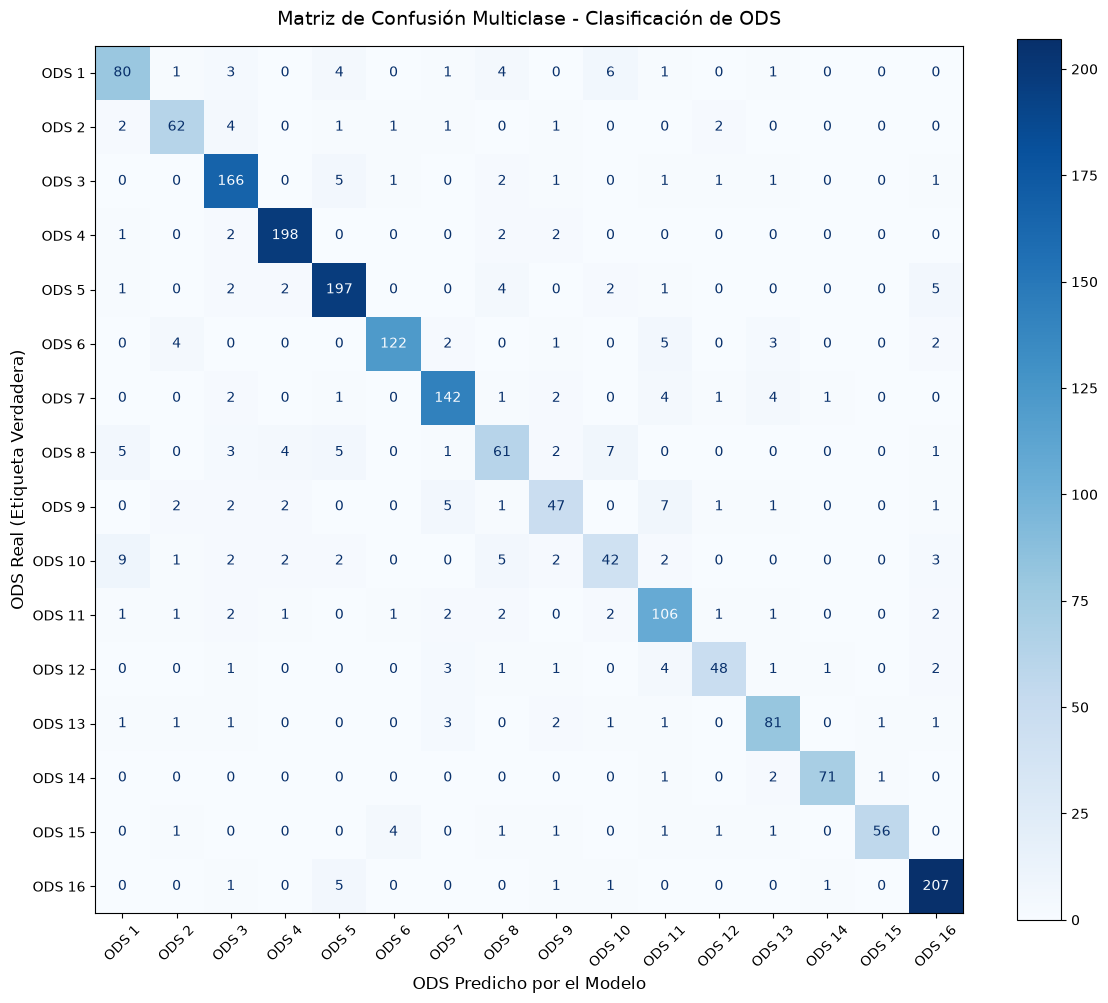

In [28]:
# ==============================================================================
# VISUALIZACIÓN GRÁFICA DE LA MATRIZ DE CONFUSIÓN (CONJUNTO TEST)
# ==============================================================================

# Generar la matriz numérica de aciertos y desaciertos
cm = confusion_matrix(y_test, y_pred_test)

# Etiquetas cortas para los ejes correspondientes a las 16 clases evaluadas
etiquetas_ejes = [f"ODS {i}" for i in sorted(y_test.unique())]

fig, ax = plt.subplots(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas_ejes)

# Despliegue con mapa de colores y rotación de etiquetas para legibilidad
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, colorbar=True)

plt.title("Matriz de Confusión Multiclase - Clasificación de ODS", fontsize=14, pad=15)
plt.xlabel("ODS Predicho por el Modelo", fontsize=12)
plt.ylabel("ODS Real (Etiqueta Verdadera)", fontsize=12)
plt.grid(False)
plt.tight_layout()
plt.show()

### Análisis de la Matriz de Confusión

Al revisar la distribución de las predicciones frente a las etiquetas reales del conjunto de prueba (1.932 documentos repartidos en las 16 clases evaluadas), se destacan varios aspectos del comportamiento del modelo:

* **Concentración en la diagonal principal:**  
  La mayor parte de los datos se agrupa a lo largo de la diagonal, lo que respalda de forma directa el porcentaje global de acierto alcanzado (86.02%). Las clases que mostraron un desempeño más limpio y con menos desvíos fueron:
  * **ODS 16 (Paz, justicia e instituciones sólidas):** 207 aciertos sobre 216 textos reales, con apenas 9 casos dispersos.
  * **ODS 4 (Educación de calidad):** 198 aciertos de 205 posibles.
  * **ODS 5 (Igualdad de género):** 197 aciertos de 214 registros.
  * **ODS 3 (Salud y bienestar):** 166 aciertos de 179 casos.
  * **ODS 7 (Energía asequible y no contaminante):** 142 aciertos de 158 documentos.

* **Revisión de los errores y cruces más frecuentes:**  
  Mirando con detalle las filas de las categorías que tuvieron métricas más bajas en el reporte (ODS 10, ODS 8 y ODS 9), la matriz muestra con claridad hacia dónde se fueron esas malas clasificaciones:
  * **ODS 10 (Reducción de las desigualdades) frente a ODS 1 y ODS 8:** De los 70 textos reales del ODS 10, solo 42 se catalogaron bien. Hubo 9 textos que el modelo asignó al ODS 1 (Fin de la pobreza) y 5 al ODS 8 (Trabajo decente). Esto tiene sentido a nivel de vocabulario, ya que debatir sobre brechas salariales, distribución de renta o subsidios utiliza palabras muy similares a las empleadas en iniciativas contra la pobreza o sobre el mercado laboral.
  * **ODS 8 (Trabajo decente y crecimiento económico) hacia ODS 10, ODS 1 y ODS 5:** De 89 registros, se acertaron 61. Los desaciertos se repartieron principalmente hacia ODS 10 (7 textos), ODS 1 (5 textos) y ODS 5 (5 textos), este último atribuible a textos que abordan empleo femenino o equidad salarial por género.
  * **ODS 9 (Industria, innovación e infraestructura) hacia ODS 11 y ODS 7:** Obtuvo 47 aciertos sobre 69 textos. Las confusiones se fueron hacia ODS 11 (Ciudades y comunidades sostenibles, con 7 casos) y ODS 7 (Energía, con 5 casos), donde suele haber un léxico compartido sobre transporte público, infraestructura urbana y modernización de redes.
  * **ODS 1 (Fin de la pobreza) hacia ODS 10 y ODS 8:** Se registraron 6 fallos hacia ODS 10 y 4 hacia ODS 8, confirmando que las tres categorías de corte económico comparten un vocabulario base difícil de aislar por completo.

* **Balance general:**  
  Los errores que comete el clasificador no son aleatorios; ocurren justamente entre metas que abordan problemáticas socioeconómicas conectadas entre sí dentro de la Agenda 2030 para el desarrollo social. Aun así, la reducción de variables aplicada con la descomposición matricial logra conservar las diferencias clave y mantiene una separación sólida en la gran mayoría de los objetivos evaluados.

Con base a lo anterior se puede concluir que el modelo demuestra ser robusto y apto para producción, superando el 83% en F1-Macro. La reducción de dimensionalidad LSA con 100 componentes logró comprimir eficazmente el espacio vectorial TF-IDF y por ende proporciona buena capacidad discriminativa de clases.

## 9. Evidencia clasificación del modelo.

Para evidenciar el desempeño del método construido el notebook debe mostrar las clasificaciones para al menos cuatro textos del conjunto test.

El siguiente bloque de código tiene como propósito
inspeccionar visual e individualmente el comportamiento del modelo sobre muestras aleatorias del conjunto de prueba (x_test). Adicionalmente mostrar el texto parcial original, la etiqueta real, la clase predicha y el nivel de certidumbre/confianza asignado por la Regresión Logística.

In [29]:
# 1. Recuperar el pipeline óptimo y extraer predicciones categóricas y probabilísticas
best_pipeline = grid_ods.best_estimator_

y_pred_test = best_pipeline.predict(x_test)
y_proba_test = best_pipeline.predict_proba(x_test)

# 2. Selección de Muestras Aleatorias Reproducibles
# Se fijan 5 registros de prueba mediante una semilla fija para reproducibilidad sobre las muestras no vistas
np.random.seed(42)
indices_muestra = np.random.choice(len(x_test), size=5, replace=False)

print("=" * 85)
print("EVIDENCIA DE CLASIFICACIÓN SOBRE TEXTOS NO VISTOS EN EL ENTRENAMIENTO (TEST)")
print("=" * 85 + "\n")

# ------------------------------------------------------------------------------
# 3. Iteración e Inspección Individual de Registro
# ------------------------------------------------------------------------------
for i, idx in enumerate(indices_muestra, start=1):
    texto_original = x_test.iloc[idx]
    ods_real_num = y_test.iloc[idx]
    ods_pred_num = y_pred_test[idx]

    # Obtener el nombre traducido usando el diccionario de ODS construido antes
    ods_real_nombre = ods_nombres.get(ods_real_num, f"ODS {ods_real_num}")
    ods_pred_nombre = ods_nombres.get(ods_pred_num, f"ODS {ods_pred_num}")

    # Obtener la probabilidad del ODS predicho
    clases_pipeline = list(best_pipeline.classes_)
    pos_clase = clases_pipeline.index(ods_pred_num)
    confianza = y_proba_test[idx][pos_clase] * 100

    # Verificación de concordancia entre la etiqueta real y la predicción
    es_correcto = ods_real_num == ods_pred_num
    estado = "CORRECTO (Acierto)" if es_correcto else "INCORRECTO (Desacierto)"

    # Impresión estructurada de resultados por muestra
    print(f"--- Muestra Test #{i} [{estado}] ---")
    print(f"Texto: \"{texto_original[:220]}...\"")
    print(f"  • ODS Real: [{ods_real_num}] {ods_real_nombre}")
    print(f"  • ODS Predicho por Modelo: [{ods_pred_num}] {ods_pred_nombre}")
    print(f"  • Nivel de Confianza:      {confianza:.2f}%\n")

print("=" * 85)

EVIDENCIA DE CLASIFICACIÓN SOBRE TEXTOS NO VISTOS EN EL ENTRENAMIENTO (TEST)

--- Muestra Test #1 [CORRECTO (Acierto)] ---
Texto: "Los deciles de ingresos son útiles para determinar diferentes posiciones en la distribución general de renta. Por ejemplo, alguien que trabaja a tiempo completo con el salario promedio tiene garantizada su ubicación en l..."
  • ODS Real: [10] ODS 10: Reducción de las desigualdades
  • ODS Predicho por Modelo: [10] ODS 10: Reducción de las desigualdades
  • Nivel de Confianza:      60.68%

--- Muestra Test #2 [CORRECTO (Acierto)] ---
Texto: "Las autoridades de todos los ámbitos tienen un papel significativo en la gestión de residuos. Es esencial realizar un balance de las iniciativas políticas para lograr la reducción a largo plazo y establecer un sistema so..."
  • ODS Real: [12] ODS 12: Producción y consumo responsables
  • ODS Predicho por Modelo: [12] ODS 12: Producción y consumo responsables
  • Nivel de Confianza:      90.44%

--- Muestra Test #3 [COR

### Conclusiones principales:

El modelo clasificó correctamente 4 de los 5 textos presentados (80% de precisión en la muestra), lo que valida en la práctica la métrica global de Accuracy (86.02%) alcanzada sobre datos no vistos.

En los aciertos claros (Muestras #2, #3 y #5), el modelo asignó probabilidades elevadas (91.43%, 94.37% y 98.09%).

En el ODS 10 (Reducción de las Desigualdades), la muestra fue clasificada correctamente pese a la complejidad semántica.

En la Muestra #4, el modelo falló al predecir ODS 6 (Agua Limpia) en lugar de ODS 9 (Industria/Infraestructura).

## **Creación de aplicación en Streamlit:**

### Link para ejecutar aplicación interactiva utilizando Streamlit:
[app_ODS_Streamlit](https://clasificador-ods-9mb7mgz56gua7uhmmthdbq.streamlit.app/)

### **Autores:**

Jose Luis Sarta Alvarez. Código: 202612984

Marco Julio Gómez Amado. Código: 199918013